In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 9,
    "axes.labelsize": 9,
    "legend.fontsize": 9,
    "xtick.labelsize": 8,
})

In [ ]:
TEMP = 23 #celcius
HUMIDITY = 61 #%
PRESSURE = 992e2 / 133.322387415 #mmhg
DENSITY = (0.46455 * PRESSURE - 61 * (0.00252 * TEMP - 0.020582)) / (TEMP + 273.15) #kg/m3
print(DENSITY)

H_ATM = 136
H_PITOT = 14.65
CORDLENGTH = 150

plot_configs = [
    ('0deg', '0', 'indianred'),
    ('6deg', '6', 'steelblue'),
    ('minus4deg', '-4', 'lightseagreen')
]

1.1594581064279144


In [23]:
col = ['tap', 'x', 'surface', 'H_0deg', 'H_6deg', 'H_minus4deg']
df = pd.read_csv('naca0012_ex1.csv', sep=',', skiprows=1, names=col)

print(df)

    tap      x surface  H_0deg  H_6deg  H_minus4deg
0     0    0.0      LE     121     125          123
1     1    7.5   Upper     139     157          132
2     2    7.5   Lower     140     127          150
3     3   15.0   Upper     139     156          135
4     4   15.0   Lower     140     132          146
5     5   22.5   Upper     139     145          136
6     6   22.5   Lower     140     133          144
7     7   30.0   Upper     139     145          136
8     8   30.0   Lower     140     133          143
9     9   45.0   Upper     138     143          137
10   10   45.0   Lower     139     133          142
11   11   60.0   Upper     139     141          137
12   12   60.0   Lower     139     134          142
13   13   75.0   Upper     139     139          138
14   14   75.0   Lower     139     135          141
15   15   90.0   Upper     139     138          139
16   16   90.0   Lower     139     135          140
17   17  105.0   Upper     139     137          138
18   18  105

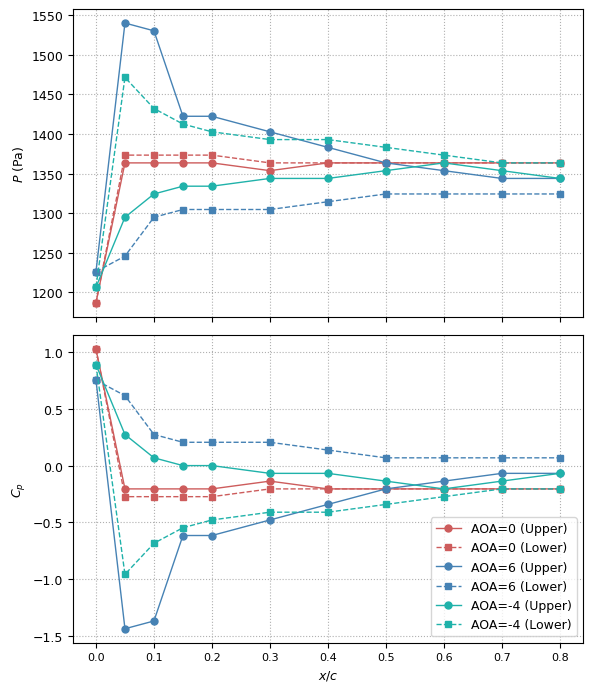

In [64]:
for suffix, aoa_val, color in plot_configs:
    df[f'P_{suffix}'] = 1000 * 9.81 * df[f'H_{suffix}'] * 0.001
    df[f'Cp_{suffix}'] = (H_ATM - df[f'H_{suffix}']) / H_PITOT

df['x_c'] = df['x'] / CORDLENGTH
df_upper = df[df['surface'].isin(['LE', 'Upper'])]
df_lower = df[df['surface'].isin(['LE', 'Lower'])]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6,7), sharex=True)

for suffix, aoa_val, color in plot_configs:
    ax1.plot(df_upper['x_c'], df_upper[f'P_{suffix}'],
            label=f'AOA={aoa_val} (Upper)', marker='o', color=color, markersize=5, lw=1)
    
    ax1.plot(df_lower['x_c'], df_lower[f'P_{suffix}'], 
            label=f'AOA={aoa_val} (Lower)', marker='s', color=color, markersize=5, linestyle='--', lw=1)
    
    ax2.plot(df_upper['x_c'], df_upper[f'Cp_{suffix}'],
            label=f'AOA={aoa_val} (Upper)', marker='o', color=color, markersize=5, lw=1)
    
    ax2.plot(df_lower['x_c'], df_lower[f'Cp_{suffix}'], 
            label=f'AOA={aoa_val} (Lower)', marker='s', color=color, markersize=5, linestyle='--', lw=1)
    
ax1.set_ylabel('$P$ (Pa)')
ax1.grid(True, linestyle=':')

ax2.set_xlabel('$x/c$')
ax2.set_ylabel('$C_p$')
ax2.legend()
ax2.grid(True, linestyle=':')

plt.tight_layout()
plt.show()